# Hello world

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from collections import Counter
import time
import os

# Train/val split

In [2]:
Data_DIR = "../data/images/"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 1337
Epochs = 2

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    Data_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",

)

class_names = train_ds_raw.class_names
num_classes = len(class_names)


train_ds = train_ds_raw
val_ds = val_ds_raw


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)


Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.


In [3]:
print(IMG_SIZE + (3,), BATCH_SIZE, SEED)


(224, 224, 3) 32 1337


## Baseline and compile

In [4]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,)
)
base.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="top1"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
    ],
)

## Fit the base-model

In [208]:
history_clean = model.fit(train_ds, validation_data=val_ds, epochs=Epochs)

Epoch 1/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 144s 258ms/step - loss: 1.3006 - top1: 0.7215 - top5: 0.9249 - val_loss: 0.5711 - val_top1: 0.8435 - val_top5: 0.9862
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 127s 247ms/step - loss: 0.4916 - top1: 0.8644 - top5: 0.9895 - val_loss: 0.4766 - val_top1: 0.8593 - val_top5: 0.9883


## Corrupt

### Random noice

In [5]:
def add_noise(img, label, std=255.0,mean=-50.0):
    noise = tf.random.normal(tf.shape(img), mean=mean, stddev=std)
    img = tf.clip_by_value(img + noise, 0.0, 255.0)
    return img, label

val_ds_noise = (val_ds_raw
                .map(lambda img, label: add_noise(img, label, std=40.0)))

### Jpeg compression

In [6]:
def jpeg_compression(img, label, quality=1):
    img = tf.cast(img, tf.uint8)                 
    x = tf.io.encode_jpeg(img, quality=quality)
    img = tf.io.decode_jpeg(x, channels=3)
    img = tf.cast(img, tf.float32)
    return img, label


val_ds_jpeg = (val_ds_raw
               .unbatch()
               .map(lambda x, y: jpeg_compression(x, y),)
               .batch(BATCH_SIZE))

### Blur

In [7]:
def blur(img, label, k=5):
    img4 = tf.expand_dims(img, 0) 
    img4 = tf.nn.avg_pool2d(img4, ksize=k, strides=1, padding="SAME")
    img = tf.squeeze(img4, 0)      
    return img, label

val_ds_blur = (val_ds_raw
               .unbatch()
               .map(lambda x, y: blur(x, y),)
               .batch(BATCH_SIZE))


## Corrupt some input data

In [8]:
def corrupt_fraction(train_ds_raw, corrupt_fn, p=0.5, seed=SEED, batch_size=32, shuffle=True):

    ds = train_ds_raw.unbatch().enumerate() # Add an index to each element

    def maybe_corrupt(i, data): 
        img, label = data 

        # Create a random number in [0, 1) using a stateless random generator
        r = tf.random.stateless_uniform(
            shape=[], 
            seed=tf.stack([tf.cast(seed, tf.int32), tf.cast(i, tf.int32)]), # Use the index as part of the seed to ensure different random numbers for each element
            
        )
    
        return tf.cond(
            r < p,
            lambda: corrupt_fn(i, img, label), # true case: apply corruption
            lambda: (img, label) # false case: return original
        )

    ds = ds.map(maybe_corrupt)
    # if shuffle:
    #     ds = ds.shuffle(2000, seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    return ds

In [12]:
def mixed_corruption(i, img, label):
    i = tf.cast(i, tf.int32)

    r_type = tf.random.stateless_uniform(
        shape=[],
        seed=tf.stack([tf.constant(SEED + 1, tf.int32), i])
    )

    return tf.case(
        [
            (r_type < 1/3, lambda: blur(img, label, k=5)),
            (r_type < 2/3, lambda: add_noise(img, label, std=25.0)),
        ],
        default=lambda: jpeg_compression(img, label, quality=30),
        exclusive=False
    )

# Ny
1. for looop mmed ex jpeg 1% 5% 15% på training data sen evaluate
2. vad den gissar fel/rätt på
3. leder corrupt trändata till ökad prestetaion på rätt korrupt data
4. tensorflowboard
5. vad den gissar för classer


1. corrupt_fraction för att få andel % corrupt/ range för hur mycket corruption
2. corrupta olika mycket  

In [9]:
def build_model():
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=IMG_SIZE + (3,)
    )
    base.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5"),
        ],
    )
    return model

In [10]:
def make_callbacks(corruption_name, p):
    run_name = f"{corruption_name}_p{int(p*100)}_{datetime.now().strftime('%Y%m%d-%H%M%S')}"
    log_dir = os.path.join("logs", run_name)

    tb = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir,
        histogram_freq=0,
        write_graph=True,
        update_freq="batch",
        profile_batch=0
    )

    return [tb], log_dir

In [11]:
def collect_predictions(model, ds):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in ds:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)

    return np.array(y_true), np.array(y_pred), np.array(y_prob)

In [13]:
corruption_levels = [1]

# corruptions = {
#     "blur": lambda img, label: blur(img, label),
#     "noise": lambda img, label: add_noise(img, label),
#     "jpeg": lambda img, label: jpeg_compression(img, label),
# }

In [14]:
results = []
predictions_store = []

for p in corruption_levels:
    print(f"Training with {(p*100)}% corrupted images with")


    train_variant = corrupt_fraction(
        train_ds_raw,
        corrupt_fn=mixed_corruption,
        p=p,
        seed=SEED,
        batch_size=BATCH_SIZE,
    )

    model = build_model()
    callbacks, log_dir = make_callbacks("mixed", p)

    start = time.perf_counter()

    history = model.fit(
        train_variant,
        validation_data=val_ds,
        epochs=Epochs,
        callbacks=callbacks
    )

    train_time = time.perf_counter() - start

    val_loss, val_top1, val_top5 = model.evaluate(val_ds, verbose=0)
    
    y_true, y_pred, y_prob = collect_predictions(model, val_ds)

    predictions_store.append({
        "corruption_type": "mixed",
        "p": p,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
    })


    results.append({
        "corruption_type": "mixed",
        "p": p,
        "history" : history.history,
        "val_loss": val_loss,
        "val_top1": val_top1,
        "val_top5": val_top5,
        "train_time": train_time,
        "log_dir": log_dir
    })

Training with 100% corrupted images with
Epoch 1/2
    515/Unknown 100s 187ms/step - accuracy: 0.4425 - loss: 2.6491 - top5: 0.7034

c:\Users\Emil\Desktop\skola\BDP\BDP\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


515/515 ━━━━━━━━━━━━━━━━━━━━ 125s 236ms/step - accuracy: 0.5841 - loss: 1.7986 - top5: 0.8526 - val_accuracy: 0.8200 - val_loss: 0.6623 - val_top5: 0.9825
Epoch 2/2
515/515 ━━━━━━━━━━━━━━━━━━━━ 115s 224ms/step - accuracy: 0.7397 - loss: 0.9330 - top5: 0.9488 - val_accuracy: 0.8372 - val_loss: 0.5346 - val_top5: 0.9854


In [15]:
history.history

{'accuracy': [0.5841229557991028, 0.73967444896698],
 'loss': [1.7985869646072388, 0.9329856038093567],
 'top5': [0.8526481986045837, 0.9487974047660828],
 'val_accuracy': [0.8199708461761475, 0.8372206091880798],
 'val_loss': [0.6622915267944336, 0.5345936417579651],
 'val_top5': [0.9825072884559631, 0.9854227304458618]}

In [19]:
def class_accuracy_report(predictions_store, corruption_type, p, class_names, top_n=5):
    run = None
    for r in predictions_store:
        if r["corruption_type"] == corruption_type and r["p"] == p:
            run = r
            break

    if run is None:
        print("Ingen matchande körning hittades.")
        return

    y_true = run["y_true"]
    y_pred = run["y_pred"]

    per_class = []

    for class_idx, class_name in enumerate(class_names):
        mask = (y_true == class_idx)
        total = np.sum(mask)

        if total == 0:
            continue

        correct = np.sum(y_pred[mask] == y_true[mask])
        acc = correct / total

        per_class.append({
            "class_idx": class_idx,
            "class_name": class_name.split("-")[1], # Ta bara första delen av klassnamnet
            "total": total,
            "correct": correct,
            "accuracy": acc,
        })

    per_class = sorted(per_class, key=lambda x: x["accuracy"], reverse=True)

    print("\nMest rätt på:")
    for row in per_class[:top_n]:
        print(f'{row["class_name"]:30s} acc={row["accuracy"]:.3f} ({row["correct"]}/{row["total"]})')

    print("\nMest fel på:")
    for row in per_class[-top_n:]:
        print(f'{row["class_name"]:30s} acc={row["accuracy"]:.3f} ({row["correct"]}/{row["total"]})')

In [20]:
class_accuracy_report(predictions_store, "mixed", 1, class_names)


Mest rätt på:
Bedlington_terrier             acc=1.000 (39/39)
Irish_setter                   acc=1.000 (27/27)
Irish_water_spaniel            acc=1.000 (24/24)
Saint_Bernard                  acc=1.000 (32/32)
Samoyed                        acc=1.000 (43/43)

Mest fel på:
toy_terrier                    acc=0.500 (17/34)
miniature_poodle               acc=0.444 (12/27)
Staffordshire_bullterrier      acc=0.433 (13/30)
Yorkshire_terrier              acc=0.417 (10/24)
Eskimo_dog                     acc=0.125 (5/40)


In [21]:

def top_confusions(predictions_store, corruption_type, p, class_names, top_n=15):
    run = None
    for r in predictions_store:
        if r["corruption_type"] == corruption_type and r["p"] == p:
            run = r
            break

    if run is None:
        print("Ingen matchande körning hittades.")
        for r in predictions_store:
            print(f'  corruption_type={r["corruption_type"]}, p={r["p"]}')
        return

    y_true = run["y_true"]
    y_pred = run["y_pred"]

    wrong_pairs = [(t, pred) for t, pred in zip(y_true, y_pred) if t != pred]
    counts = Counter(wrong_pairs).most_common(top_n)

    print(f"\nVanligaste felgissningar för {corruption_type}, p={p}:")
    for (true_idx, pred_idx), count in counts:
        print(
            f"True: {class_names[int(true_idx)].split('-')[1]:30s} "
            f"Pred: {class_names[int(pred_idx)].split('-')[1]:30s} "
            f"Count: {count}"
        )

In [22]:
top_confusions(predictions_store, "mixed", 1, class_names, top_n=10)


Vanligaste felgissningar för mixed, p=1:
True: Eskimo_dog                     Pred: Siberian_husky                 Count: 28
True: Staffordshire_bullterrier      Pred: American_Staffordshire_terrier Count: 12
True: Yorkshire_terrier              Pred: silky_terrier                  Count: 10
True: English_foxhound               Pred: beagle                         Count: 9
True: whippet                        Pred: Italian_greyhound              Count: 8
True: Shih                           Pred: Lhasa                          Count: 8
True: collie                         Pred: Border_collie                  Count: 7
True: miniature_poodle               Pred: toy_poodle                     Count: 7
True: Cardigan                       Pred: Pembroke                       Count: 7
True: standard_schnauzer             Pred: miniature_schnauzer            Count: 7


## Print

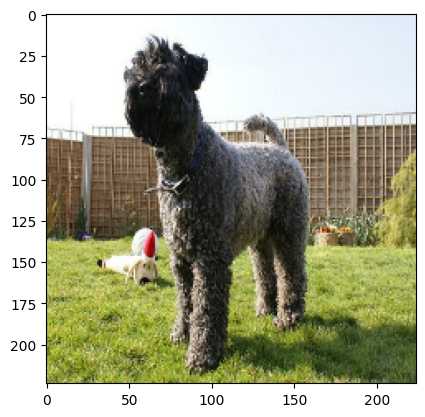

In [ ]:
for images, labels in val_ds_raw.take(1):
    original = images[0]
    break

noisy, _ = add_noise(original, None, std=40.0)
jpeg, _ = jpeg_compression(original, None, quality=20)
blurred, _ = blur(original, None)

plt.imshow(original.numpy().astype("uint8"))


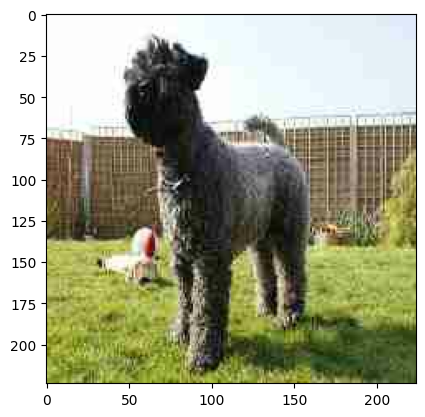

In [ ]:
plt.imshow(jpeg.numpy().astype("uint8"))


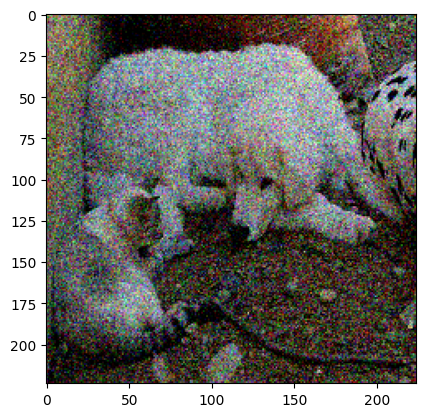

In [ ]:
plt.imshow(noisy.numpy().astype("uint8"))


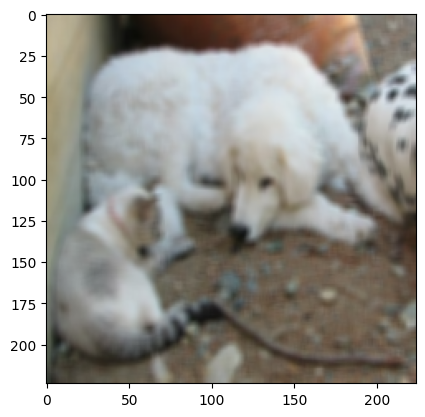

In [ ]:
plt.imshow(blurred.numpy().astype("uint8"))

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir logs

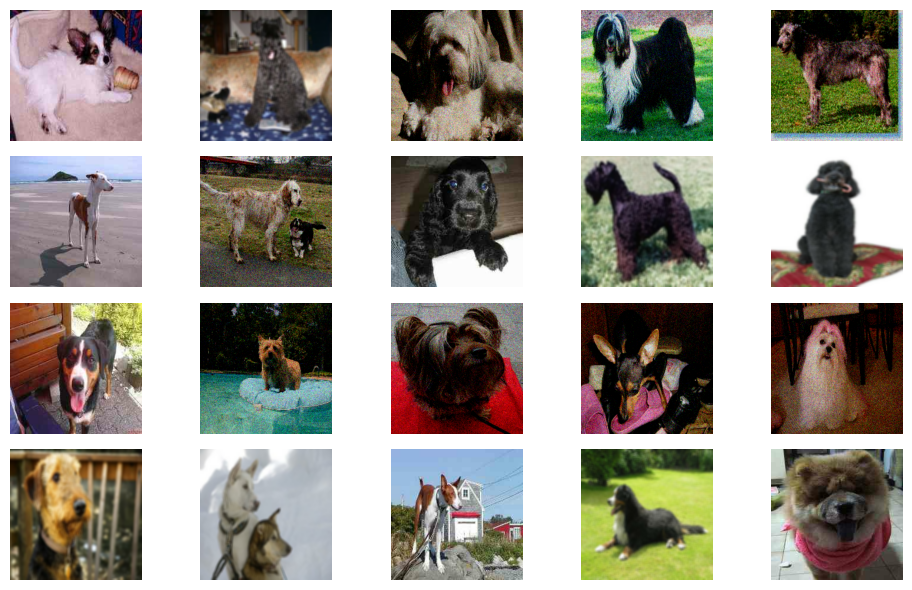

In [25]:
import matplotlib.pyplot as plt

for images, labels in train_variant.take(1):
    plt.figure(figsize=(10, 6))
    for i in range(20):
        plt.subplot(4, 5, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8).numpy())
        plt.axis("off")
    plt.tight_layout()
    plt.show()